In [17]:
from langgraph.graph import StateGraph, START, END
from  langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

from dotenv import load_dotenv
from typing import TypedDict, Literal, Annotated
from langgraph.prebuilt import ToolNode

load_dotenv()

True

In [3]:
from langchain_core.tools import tool
import requests


@tool
def get_weather(location:str) -> str:
    """Get current weather for a location.
    
    Use for queries about weather, temperature, or conditions in any city.
    Examples: "weather in Paris", "temperature in Tokyo", "is it raining in London"
    
    Args:
        location: City name (e.g., "New York", "London", "Tokyo")
        
    Returns:
        Current weather information including temperature and conditions.
    """

    url = f"https://wttr.in/{location}?format=j1"
    response = requests.get(url, timeout=10)

    response.raise_for_status()
    data = response.json()

    return data

@tool
def calculate(expression: str) -> str:
    """Calculate a mathematical expression.
    
    USE THIS TOOL FOR:
    - Any mathematical calculations or arithmetic operations
    - Queries involving numbers and operators (+, -, *, /, **, %)
    - Questions asking to compute, calculate, or solve math problems
    - Evaluating mathematical expressions
    
    EXAMPLE QUERIES:
    - "What is 2 + 2?"
    - "Calculate 15 times 7"
    - "Solve 100 / 4"
    - "What's 5 to the power of 3?"
    - "Compute 45 * 12 + 30"
    
    DO NOT USE FOR:
    - Word problems without explicit expressions (extract the math first)
    - Questions about mathematical concepts or theory

    Args:
        expression: Math expression like "2 + 2" or "15 * 7" (use standard Python operators)
    """

    try:
        result = eval(expression)
        print(f"[TOOL] calculate ('{expression}') -> '{result}'")
    except Exception as e:
        print(f"Exception has occured with error: {e}")
        return f"Exception has occured with error: {e}"

    return result

all_tools = [get_weather, calculate]

llm = ChatOpenAI(model="gpt-4o-mini")

In [ ]:
import operator
class AgenticState(TypedDict):
    messages : Annotated[list, operator.add]
    result : str

In [ ]:
def agent_node(state: AgenticState):
    llm_with_tool= llm.bind_tools(all_tools)
    messages = state['messages']
    response = llm_with_tool.invoke(messages)

    if hasattr(response, 'tool_calls') and response.tool_calls:
        for tc in response.tool_calls:
            print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")

    else:
        print(f"[AGENT] Responding...")
        

    return {'messages': [response]}


     

def should_continue(state: AgenticState):
    last = state['messages'][-1]
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return 'tools'
    else:
        return END


In [18]:
builder = StateGraph(AgenticState)
builder.add_node("agent", agent_node)
builder.add_node('tools', ToolNode(all_tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", should_continue,['tools', END])
builder.add_edge('tools', 'agent')
memory = MemorySaver()
agent = builder.compile(checkpointer=memory)


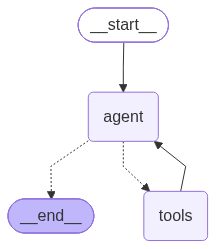

In [19]:
agent

In [21]:
config_1 = {"configurable": {"thread_id": "chat-1"}}

query = "What is the current weather in Mumbai?"
result = agent.invoke({'messages':[HumanMessage(content=query)]}, config=config_1)

[AGENT] called Tool get_weather with args {'location': 'Mumbai'}
[AGENT] Responding...


In [24]:
config_1 = {"configurable": {"thread_id": "chat-2"}}


In [25]:
query = "based on temp what clothes you recommend"
result = agent.invoke({'messages':[HumanMessage(content=query)]}, config=config_1)

[AGENT] Responding...


In [26]:
result

{'messages': [HumanMessage(content='based on temp what clothes you recommend', additional_kwargs={}, response_metadata={}),
  AIMessage(content='To give you the best clothing recommendations based on temperature, I need to know the current temperature in your area or a specific city. Could you please provide that information?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 298, 'total_tokens': 332, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2c008903e3', 'id': 'chatcmpl-EOCV8whvpq8tVDBJv82YZWBaDMnp7', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0a2bc-229a-76f2-8279-e9bb3e2883ff-0', tool_calls=[], invalid_tool_calls=[], usage_m

In [15]:
query = "what was your previous questions"
result = graph.invoke({'messages':[HumanMessage(content=query)]})

[AGENT] Responding...


In [16]:
result

{'messages': [HumanMessage(content='what was your previous questions', additional_kwargs={}, response_metadata={}),
  AIMessage(content="I'm unable to access previous questions or interactions because I don't have memory of past conversations. Each session is treated as a new interaction. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 296, 'total_tokens': 330, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2c008903e3', 'id': 'chatcmpl-EOCK7vtrqsFvYJofgxCJSRyU8ekIO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0a2b1-b772-7891-8b4a-6e96d5928a5f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'